# Iris Dataset: Simple Exploratory Data Analysis (EDA)

##### Import Modules

In [38]:
import pandas as pd
import numpy as np

# Visualisasi Data
import matplotlib.pyplot as plt 
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid", palette="deep")

[1] Dataset Overview


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal_length,sepal_width,petal_length,petal_width,species
139,6.9,3.1,5.4,2.1,virginica
20,5.4,3.4,1.7,0.2,setosa
122,7.7,2.8,6.7,2.0,virginica
82,5.8,2.7,3.9,1.2,versicolor
31,5.4,3.4,1.5,0.4,setosa



[1] Structural Information
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

[1] Data Intergrity Check
Missing Value: 0
Duplicate Rows: 3

[2] Comprehensive Statistical Analysis


,mean,median,std,variance,skewness,kurtosis
sepal_length,5.843333,5.80,0.828066,0.685694,0.314911,-0.552064
sepal_width,3.054000,3.00,0.433594,0.188004,0.334053,0.290781
petal_length,3.758667,4.35,1.764420,3.113179,-0.274464,-1.401921
petal_width,1.198667,1.30,0.763161,0.582414,-0.104997,-1.339754



[2] Class Distribution


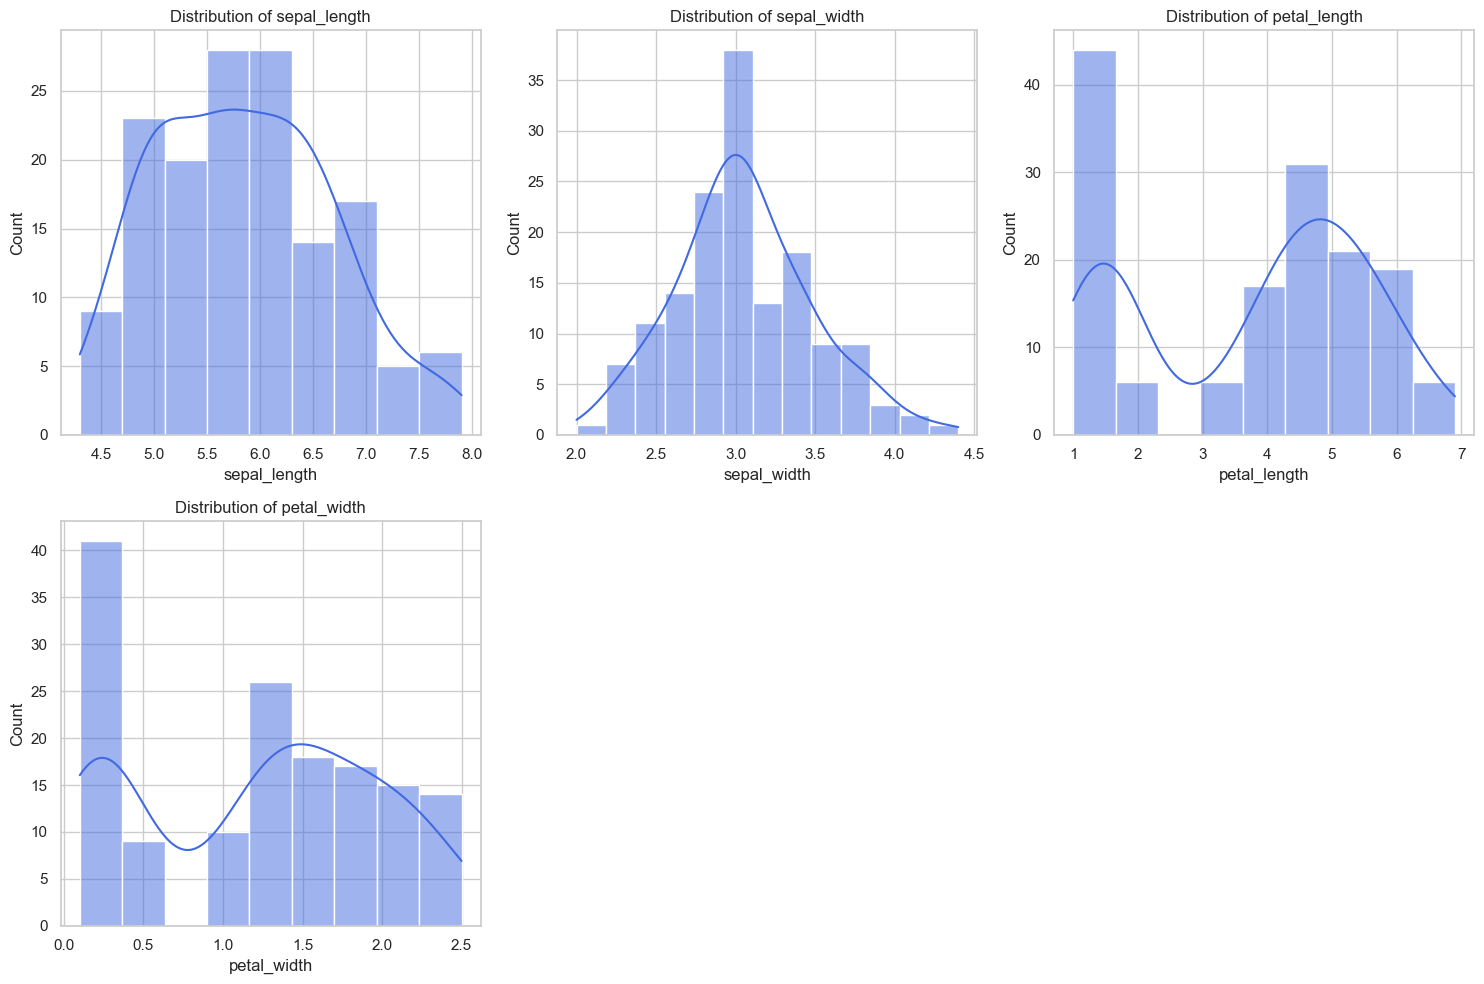

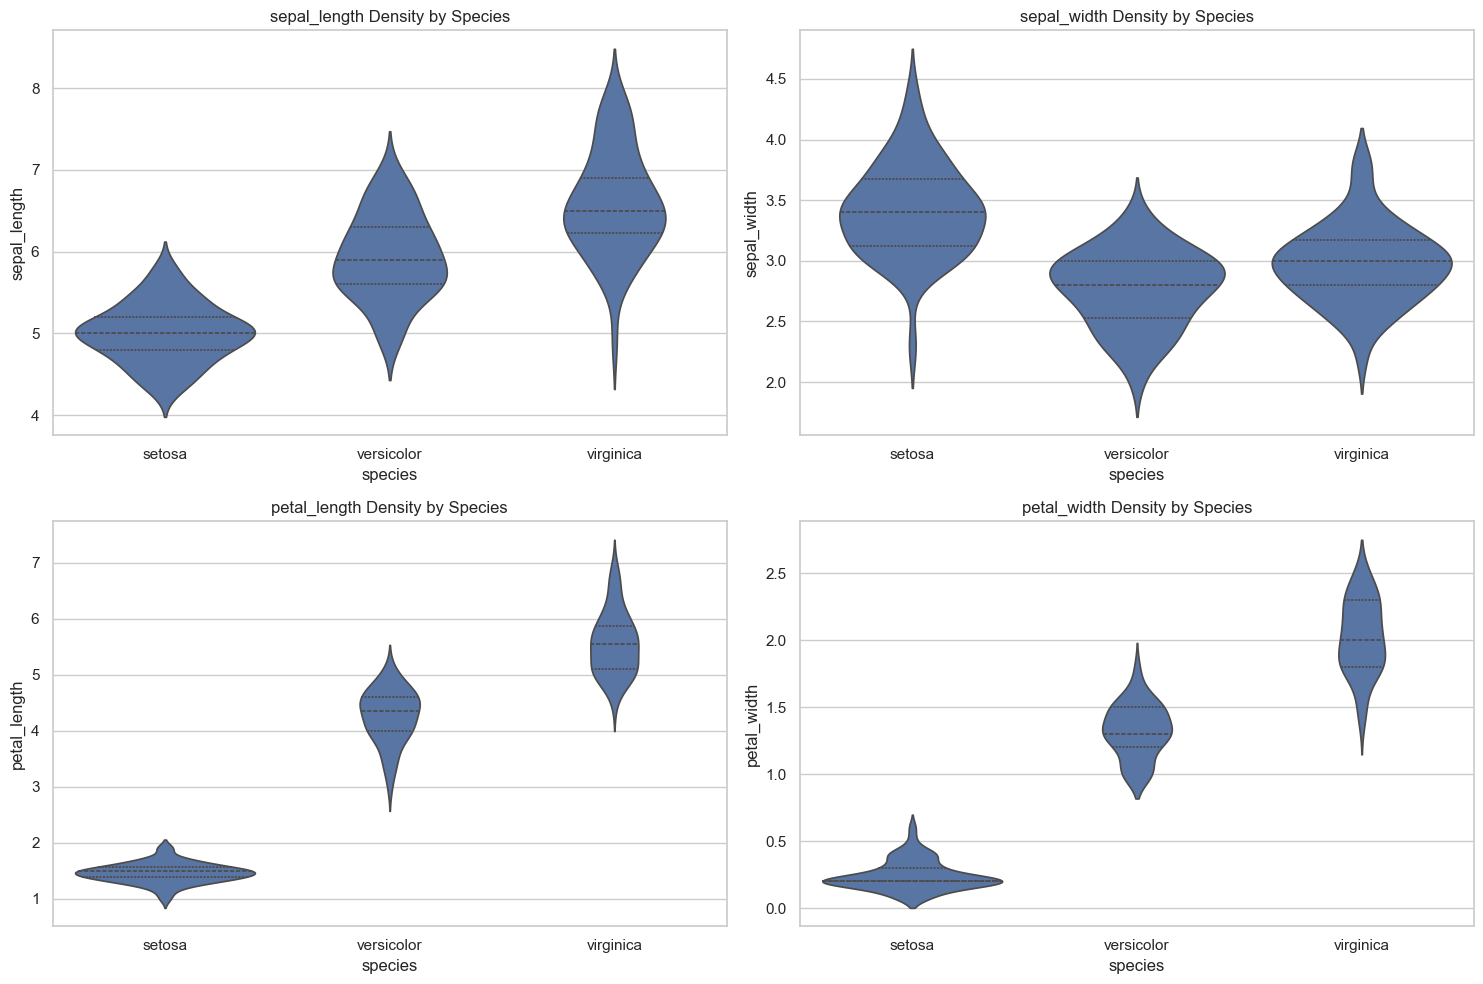

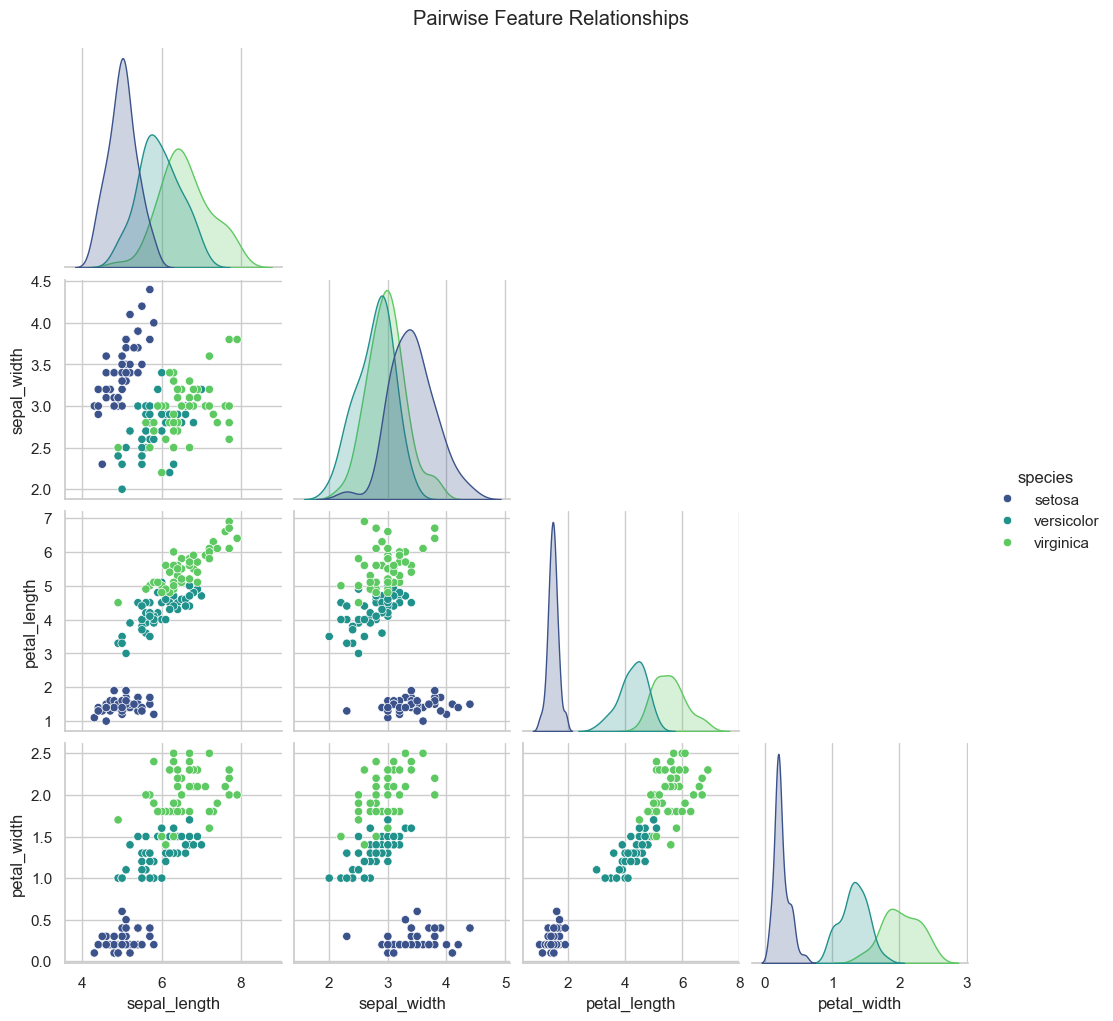

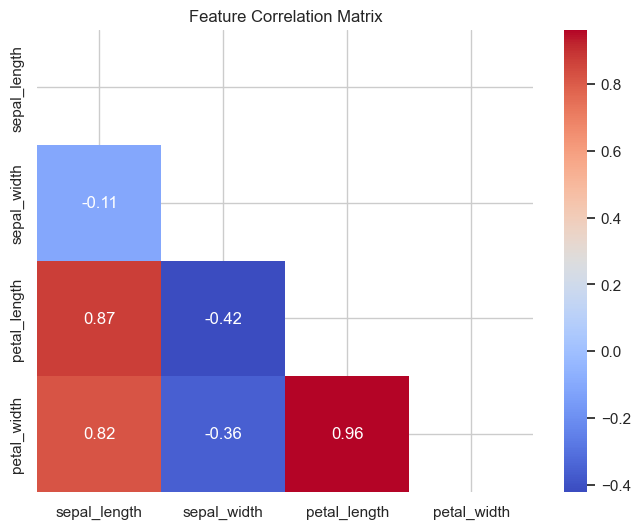

In [71]:
# 1. Load Dataset
df = pd.read_csv('../datasets/iris.csv')

print("[1] Dataset Overview")
# Menampilkan sample data dari berbagai posisi
display(df.head())
display(df.sample(5))

# Informasi struktural: Tipe data dan Memory Usage
print("\n[1] Structural Information")
df.info()

# Validasi Intergritas Data (Missing & Duplicate)
print("\n[1] Data Intergrity Check")
print(f"Missing Value: {df.isna().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

# 2. Analisis Statistik Deskriptif
# Statistik dasar (mean, median, std, range)
desc_stats = df.describe().T
desc_stats['median'] = df.median(numeric_only=True)
desc_stats['variance'] = df.var(numeric_only=True)

# Statistik lanjutan (skewness & kurtosis)
desc_stats['skewness'] = df.skew(numeric_only=True)
desc_stats['kurtosis'] = df.kurt(numeric_only=True)

print("\n[2] Comprehensive Statistical Analysis")
display(desc_stats[['mean', 'median', 'std', 'variance', 'skewness', 'kurtosis']])

# Cek keseimbangan kelas (penting buat klasifikasi)
print("\n[2] Class Distribution")
# print(df['species'].value_counts(normalize=True) * 100)

# 3. Visualisasi Data
# A. Univariate: Distribusi setiap fitur dengan KDE
plt.figure(figsize=(15,10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2,3, i+1)
    sns.histplot(df[col], kde=True, color='royalblue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# B. Multivariate: Violin Plot untuk melihat densitas dan pemisahan kelas
plt.figure(figsize=(15,10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2,2, i+1)
    sns.violinplot(x='species', y=col, data=df, inner='quartile')
    plt.title(f"{col} Density by Species")
plt.tight_layout()
plt.show()

# C. Relational: Pairplot untuk melihat korelasi visual
sns.pairplot(df, hue='species', corner=True, palette='viridis')
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

# D. Correlation Matrix: Heatmap (Triangular)
plt.figure(figsize=(8,6))
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))
sns.heatmap(df.corr(numeric_only=True), annot=True, mask=mask, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

**INSIGHT REPORT:**

- Data Integrity: Dataset memiliki 150 baris dengan 3 data duplikat yang perlu dibersihkan pada tahap preprocessing. Tidak ditemukan missing values.
- Class Balance: Distribusi target species sangat seimbang (33.3% per kelas), sehingga model tidak akan bias ke salah satu kelas.
- Linear Separability: Spesies Setosa memiliki karakteristik fitur yang sangat berbeda (terpisah secara linear) terutama pada petal_length dan petal_width dibandingkan dua spesies lainnya.
- Multicollinearity Warning: Terdapat korelasi positif yang sangat ekstrem (0.96) antara petal_length dan petal_width. Hal ini mengindikasikan bahwa salah satu fitur mungkin redundan dan bisa dipertimbangkan untuk feature selection.
- Distribution: Fitur sepal_width mendekati distribusi normal (Skewness: 0.32), sedangkan fitur kelopak (petal) cenderung bimodal karena pemisahan kelas yang tajam.

## 

# Iris Dataset: Data Pre-processing

In [36]:
print("="*80)
print("Data Pre-Processing")
print("="*80)

# ----------------------------------------------------------------------------
# 1. DATA CLEANING IMPLEMENTATION
# ----------------------------------------------------------------------------

print("\n[1] Checking missing value:")
print(df.isna().sum())

print("\n[1] Checking Duplicates:")
print("Duplicate rows:",df.duplicated().sum())


# ----------------------------------------------------------------------------
# 2. HANDLE MISSING VALUE, DUPLICATE & OUTLINER
# ----------------------------------------------------------------------------

print("\n[2] Handling Missing Value:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    if df[col].isna().sum() > 0:
        skewness = df[col].skew()

        if abs(skewness) > 1:
            df[col].fillna(df[col].media(), inplace=True)

        else:
            df[col].fillna(df[col].media(), inplace=True)
            print(f"{col}: Filled with Mean (Normal Distribution)")
print(df.isna().sum())
print("Insight: Menggunakan startegi berbeda berdasarkan distribusi data")

print("\n[2] Handling Duplicates:")
df.drop_duplicates(inplace=True)
print("Duplicate rows:",df.duplicated().sum())

print("\n[2] Handling Outliers (IQR Method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    skewness = df[col].skew()

    if abs(skewness) > 1:
        multipler = 2.0 # lebih longgar untuk data skew
    else:
        multipler = 1.5 # tetap standar 1.5

    lower_round = Q1 - multipler * IQR
    upper_round = Q3 + multipler * IQR

    df[col] = np.where(df[col] < lower_round, lower_round, df[col]) 
    df[col] = np.where(df[col] > upper_round, upper_round, df[col])

    print(f"{col}: IQR capping dengan multipler {multipler}")
print("Insight: Outliner ditangani menggunakan metode capping (IQR) agar tidak menghilangkan data penting")
print("Insight: Threshold outliner disesuaikan dengan distribusi data")

print("\n[2] Handling Skewd Distribution:")

for col in numerical_cols:
    skewness = df[col].skew()

    if abs(skewness) > 1:
        df[col] = np.log1p(df[col])
        print(f"{col}: Applied log transformation (skewness =  {skewness:.2f})")
print("Insight: Log transform membantuk menormalkan distribusi data")

# ----------------------------------------------------------------------------
# 3. FEATURE ENGINEERING
# ----------------------------------------------------------------------------

print("\n[3] Feature Engineering:")

df['petal_ratio'] = (df['petal_length'] / df['petal_width']).replace([np.inf, -np.inf], 0)
df['sepal_ratio'] = (df['sepal_length'] / df['sepal_width']).replace([np.inf, -np.inf], 0)
df['petal_area'] = (df['petal_length'] * df['petal_width'])
df['sepal_area'] = (df['sepal_length'] * df['sepal_width'])

print("Created features: petal_ratio, sepal_ratio, petal_area, sepal_area")
print("Insight: Feature ratio & area membantu meningkatkan pemisahan antar kelas")

# ----------------------------------------------------------------------------
# 4. ENCODING TARGET (KARNA KATEGORIKAL)
# ----------------------------------------------------------------------------

print("\n[4] Encoding Target...")
le = LabelEncoder()
df['species'] = pd.Series(
    le.fit_transform(df['species']), index=df.index
    )

print("Encoding Mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"{class_name} = {i}")
    

# ----------------------------------------------------------------------------
# 5. SPLIT FEATURE & TARGET
# ----------------------------------------------------------------------------

X = df.drop('species', axis=1)
y = df['species']

print("\nFeature shape:", X.shape)
print("Target Shape:", y.shape)

# ----------------------------------------------------------------------------
# 4. TRAIN TEST SPLIT
# ----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

print("\nData Split:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

# ----------------------------------------------------------------------------
# 5. FEATURE SCALING
# ----------------------------------------------------------------------------

print("\nScaling Features")
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed")
print("Insight: Scaling penting untuk model berbasis jarak seperti KNN")

# ----------------------------------------------------------------------------
# 6. DONE
# ----------------------------------------------------------------------------

print("\n"+"="*80)
print("DATA PRE-PROCESSING COMPLETED")
print("="*80)

Data Pre-Processing

[1] Checking missing value:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

[1] Checking Duplicates:
Duplicate rows: 3

[2] Handling Missing Value:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Insight: Menggunakan startegi berbeda berdasarkan distribusi data

[2] Handling Duplicates:
Duplicate rows: 0

[2] Handling Outliers (IQR Method):
sepal_length: IQR capping dengan multipler 1.5
sepal_width: IQR capping dengan multipler 1.5
petal_length: IQR capping dengan multipler 1.5
petal_width: IQR capping dengan multipler 1.5
Insight: Outliner ditangani menggunakan metode capping (IQR) agar tidak menghilangkan data penting
Insight: Threshold outliner disesuaikan dengan distribusi data

[2] Handling Skewd Distribution:
Insight: Log transform membantuk menormalkan distribusi data

[3] Feature Engineering:
Created features: petal_ratio, sepal_ratio, petal_area, 

<Axes: >

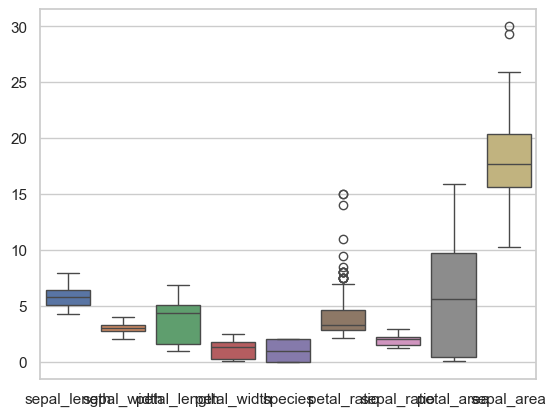

In [37]:
sns.boxplot(df)